<a href="https://colab.research.google.com/github/amazephoenix-bit/sleep-quality-predictor/blob/main/market_regime_detectiom_%26_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [75]:
data = yf.download("^GSPC",start="2015-01-01",end="2026-01-01")
data.head()

/tmp/ipykernel_3605/1995913405.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^GSPC",start="2015-01-01",end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2015-01-02,2058.199951,2072.360107,2046.040039,2058.899902,2708700000
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000


In [76]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^GSPC)   2766 non-null   float64
 1   (High, ^GSPC)    2766 non-null   float64
 2   (Low, ^GSPC)     2766 non-null   float64
 3   (Open, ^GSPC)    2766 non-null   float64
 4   (Volume, ^GSPC)  2766 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.7 KB


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
count,2766.000000,2766.000000,2766.000000,2766.000000,2.766000e+03
mean,3614.687942,3633.322880,3593.361268,3614.126862,4.106631e+09
std,1327.003332,1333.159167,1319.897467,1326.767641,1.009833e+09
min,1829.079956,1847.000000,1810.099976,1833.400024,0.000000e+00
25%,2486.332520,2502.772522,2473.129944,2485.049988,3.461245e+09
50%,3274.049927,3285.844971,3250.435059,3274.404907,3.890950e+09
75%,4448.755005,4466.119873,4429.227295,4447.640015,4.534548e+09
max,6932.049805,6945.770020,6921.600098,6936.020020,9.976520e+09


In [77]:
data.shape
data=data.dropna()
data.shape

(2766, 5)

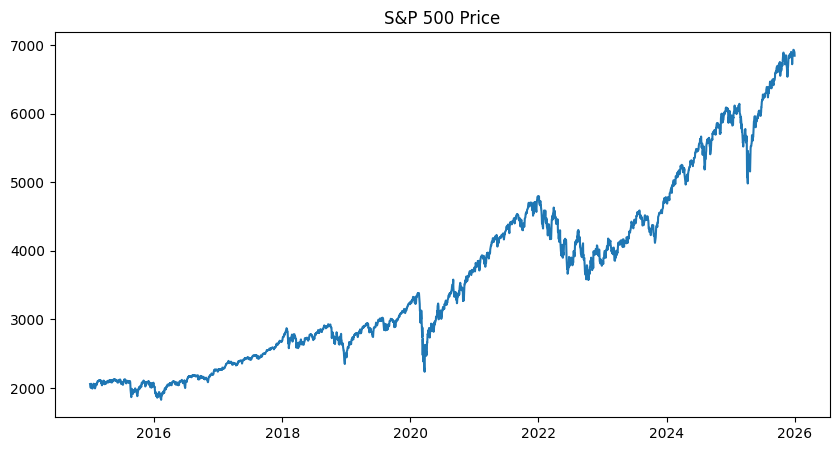

In [78]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title('S&P 500 Price')
plt.show()

In [79]:
data.to_csv("market_data.csv")

In [80]:
data['returns']=data['Close'].pct_change()

In [81]:
import numpy as np
data['log_returns']=np.log(data['Close']/data['Close'].shift(1))

In [82]:
data['volatiity_10']=data['returns'].rolling(window=10).std()
data['volatiity_30']=data['returns'].rolling(window=30).std()

In [83]:
data['ma_10']=data['Close'].rolling(window=10).mean()
data['ma_50']=data['Close'].rolling(window=50).mean()

In [84]:
data['trend']=data['ma_10']-data['ma_50']

In [85]:
data['momentum_10']=data['Close']-data['Close'].shift(10)

In [86]:
data['volume_change']=data['Volume'].pct_change()

In [87]:
data = data.dropna()
data.shape

(2717, 14)

In [88]:
freatures = [
    'log_returns',
    'volatiity_10',
    'volatiity_30',
    'trend',
    'momentum_10'
]
X = data[freatures]

In [89]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [90]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [91]:
k = 4

In [92]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,random_state=42)
clusters = kmeans.fit_predict(X_scaled)

data['regime'] = clusters

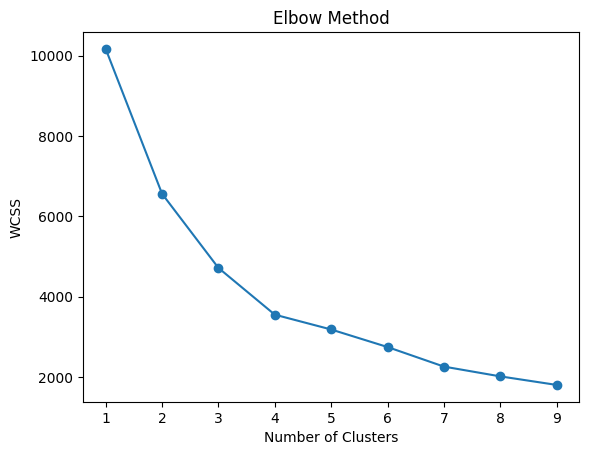

In [93]:
wcss = []

for k in range(1, 10):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_pca)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

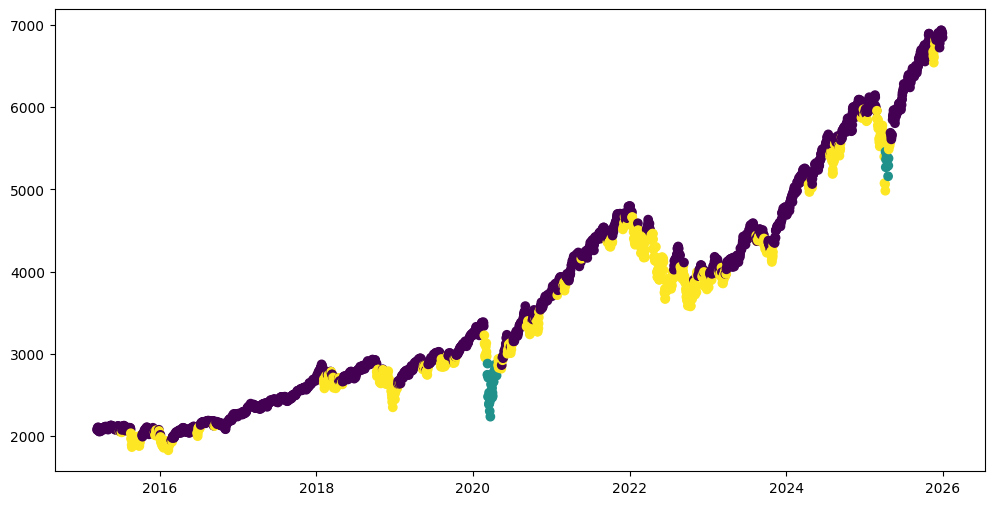

In [94]:
plt.figure(figsize=(12,6))
plt.scatter(data.index,data['Close'],c=data['regime'],cmap='viridis')

In [95]:
data.columns = [col[0] if isinstance(col, tuple)else col for col in data.columns]

In [96]:
data.groupby('regime')[freatures].mean()

,log_returns,volatiity_10,volatiity_30,trend,momentum_10
regime,,,,,
0,0.001378,0.006615,0.007562,78.033228,53.031398
1,0.000974,0.045322,0.042018,-352.167938,-79.883339
2,-0.002215,0.014075,0.013124,-61.642859,-75.538238


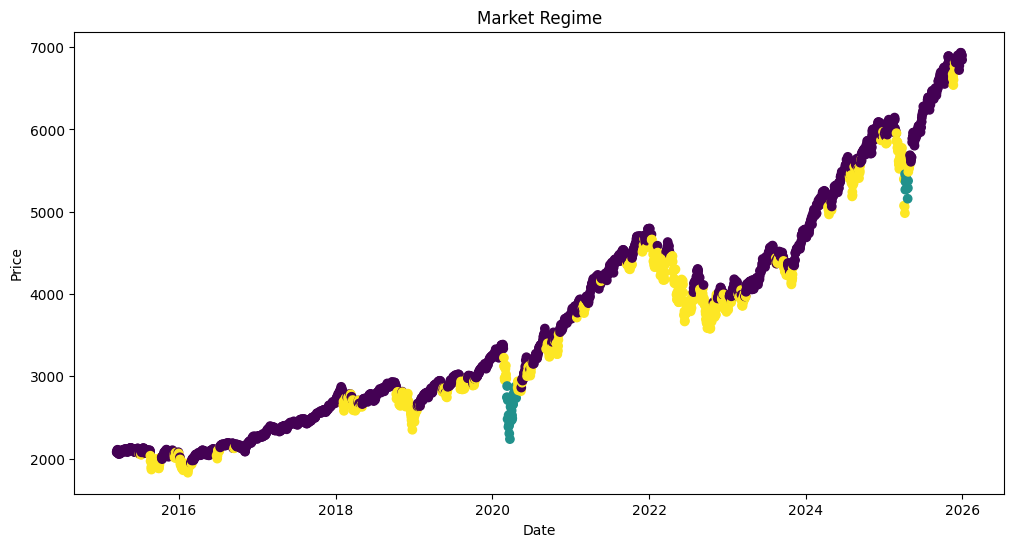

In [97]:
plt.figure(figsize=(12,6))
plt.scatter(data.index,data['Close'],c=data['regime'],cmap='viridis')
plt.title("Market Regime")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

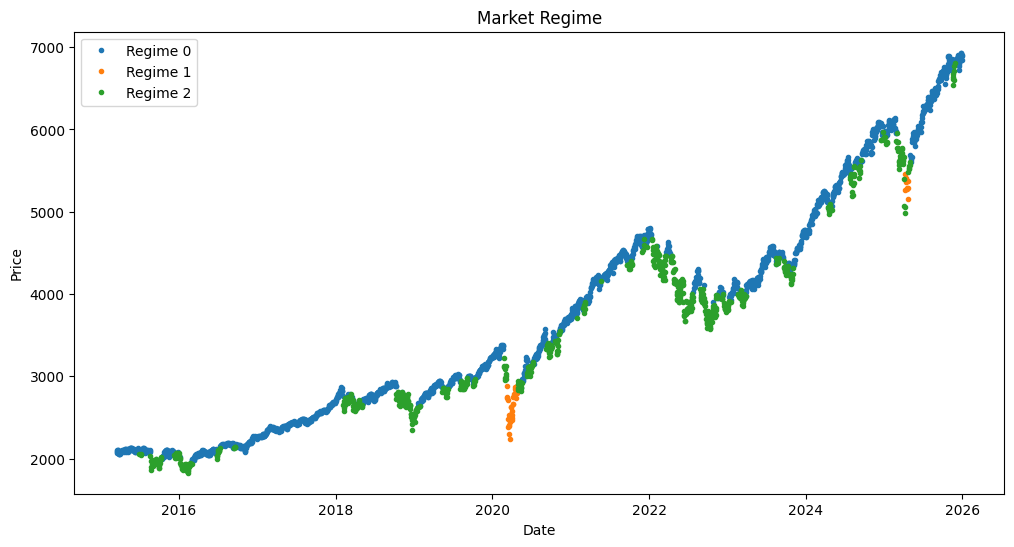

In [98]:
plt.figure(figsize=(12,6))
for i in range(data['regime'].nunique()):
  subset = data[data['regime']==i]
  plt.plot(subset.index,subset['Close'],'.',label=f'Regime {i}')
plt.title("Market Regime")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show

In [99]:
data['target'] = data['regime'].shift(-1)
data = data.dropna()

In [100]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [101]:
n = len(data)
train_end = int(0.8 * n)
val_end = int(0.9 * n)

data_train = data[:train_end].copy()
data_val = data[train_end:val_end].copy()
data_test = data[val_end:].copy()


In [102]:
X_train_scaled = scaler.fit_transform(data_train[freatures])
X_val_scaled = scaler.transform(data_val[freatures])
X_test_scaled = scaler.transform(data_test[freatures])

In [103]:
kmeans =  KMeans(n_clusters=3,random_state=42)

data_train['regime'] = kmeans.fit_predict(X_train_scaled)
data_val['regime'] = kmeans.predict(X_val_scaled)
data_test['regime'] = kmeans.predict(X_test_scaled)

In [104]:
for df in [data_train, data_val, data_test]:
  df['target'] = df['regime'].shift(-1)
  df = df.dropna(inplace = True)

In [105]:
X_train = data_train[freatures]
y_train = data_train['target']

X_val = data_val[freatures]
y_val = data_val['target']

X_test = data_test[freatures]
y_test = data_test['target']

In [106]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [108]:
from sklearn.metrics import classification_report

y_val_pred = rf.predict(X_val)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96       245
         1.0       0.40      0.24      0.30        17
         2.0       0.67      0.44      0.53         9

    accuracy                           0.92       271
   macro avg       0.67      0.55      0.60       271
weighted avg       0.90      0.92      0.91       271



In [109]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_val_pred_lr = lr.predict(X_val)
print("logistic regression")
print(classification_report(y_val, y_val_pred_lr))

logistic regression
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96       245
         1.0       0.43      0.35      0.39        17
         2.0       0.58      0.78      0.67         9

    accuracy                           0.91       271
   macro avg       0.66      0.70      0.67       271
weighted avg       0.91      0.91      0.91       271



In [110]:
from sklearn.ensemble import  GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_val_pred_gb = gb.predict(X_val)
print("Gradient Boosting")
print(classification_report(y_val, y_val_pred_gb))

Gradient Boosting
              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95       245
         1.0       0.29      0.29      0.29        17
         2.0       0.75      0.33      0.46         9

    accuracy                           0.90       271
   macro avg       0.66      0.53      0.57       271
weighted avg       0.90      0.90      0.90       271

